<a href="https://colab.research.google.com/github/Parthwadekar40/ParthCM40-Pattern-Recognition/blob/main/Prac5_PR_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Set plot style
sns.set_theme(style="whitegrid")

In [7]:
print("Loading dataset...")
retail_df = pd.read_excel('https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx')

print("\nDataset loaded successfully. Displaying first 5 rows:")
display(retail_df.head())

print("\nDataset info:")
retail_df.info()

print("\nChecking for missing values:")
print(retail_df.isnull().sum())

Loading dataset...

Dataset loaded successfully. Displaying first 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Checking for missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Remove missing CustomerIDs and Descriptions
retail_df.dropna(subset=['CustomerID', 'Description'], inplace=True)

# Convert CustomerID to integer
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)

# Remove duplicates
retail_df.drop_duplicates(inplace=True)

# Filter out non-positive quantities and prices
retail_df = retail_df[(retail_df['Quantity'] > 0) & (retail_df['UnitPrice'] > 0)]

# Calculate Total Price
retail_df['TotalPrice'] = retail_df['Quantity'] * retail_df['UnitPrice']

print("Data Cleaning Complete.")
print(f"Remaining rows: {len(retail_df):,}")
print(f"Unique customers: {retail_df['CustomerID'].nunique():,}")

Data Cleaning Complete.
Remaining rows: 392,692
Unique customers: 4,338


In [9]:
# Reference date for recency calculation (1 day past the latest transaction)
snapshot_date = retail_df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID
rfm = retail_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recency
    'InvoiceNo': 'nunique',                                       # Frequency
    'TotalPrice': 'sum'                                           # Monetary
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("RFM Features Calculated (first 5 rows):")
display(rfm.head())

print("\nRFM Summary Statistics:")
display(rfm.describe())

RFM Features Calculated (first 5 rows):


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40



RFM Summary Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [10]:
# Log transformation to reduce skewness
rfm_log = rfm.apply(lambda x: np.log1p(x))

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert back to DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)

print("RFM Features After Scaling (first 5 rows):")
display(rfm_scaled_df.head())

RFM Features After Scaling (first 5 rows):


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461993,-0.955214,3.707716
12347,-2.038734,1.074425,1.414903
12348,0.373104,0.386304,0.720024
12349,-0.623086,-0.955214,0.702287
12350,1.424558,-0.955214,-0.614514


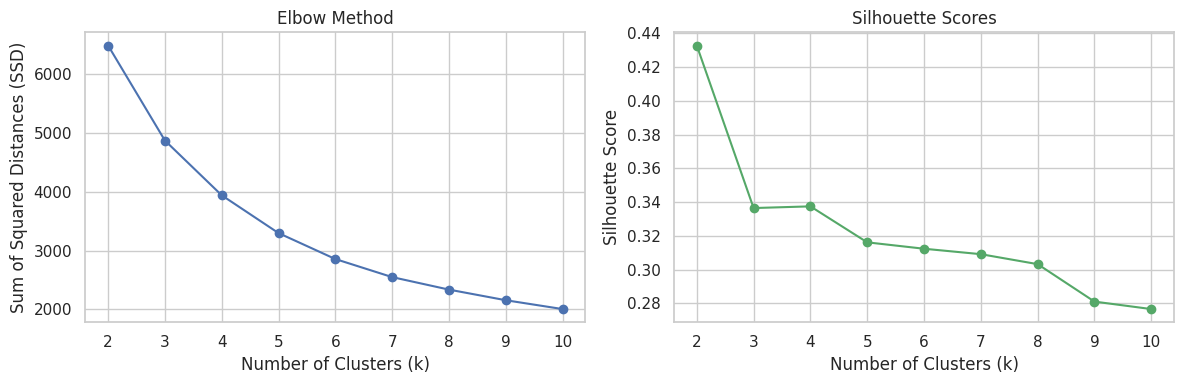

SSD values: [6483.59, 4869.49, 3939.05, 3296.71, 2855.76, 2548.82, 2336.34, 2156.01, 2005.75]
Silhouette scores: [np.float64(0.4328), np.float64(0.3365), np.float64(0.3375), np.float64(0.3162), np.float64(0.3124), np.float64(0.3092), np.float64(0.3033), np.float64(0.2811), np.float64(0.2767)]


In [11]:
k_range = range(2, 11)
ssd = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)

    ssd.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled_df, kmeans.labels_))

# Plot Elbow Curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, ssd, marker='o', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='g')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.tight_layout()
plt.show()

print("SSD values:", [round(x, 2) for x in ssd])
print("Silhouette scores:", [round(x, 4) for x in silhouette_scores])

--- K-Means Cluster Distribution (k=3) ---
KMeans_Cluster
1    1872
2    1697
0     769
Name: count, dtype: int64

--- Mean RFM Values by K-Means Cluster ---


,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,17.062419,13.348505,7898.462003
1,167.358440,1.352030,360.996448
2,44.199764,3.380082,1259.579412


/tmp/ipykernel_626/2505907925.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=rfm, palette='Set2')
/tmp/ipykernel_626/2505907925.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=rfm, palette='Set2')
/tmp/ipykernel_626/2505907925.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=rfm, palette='Set2')


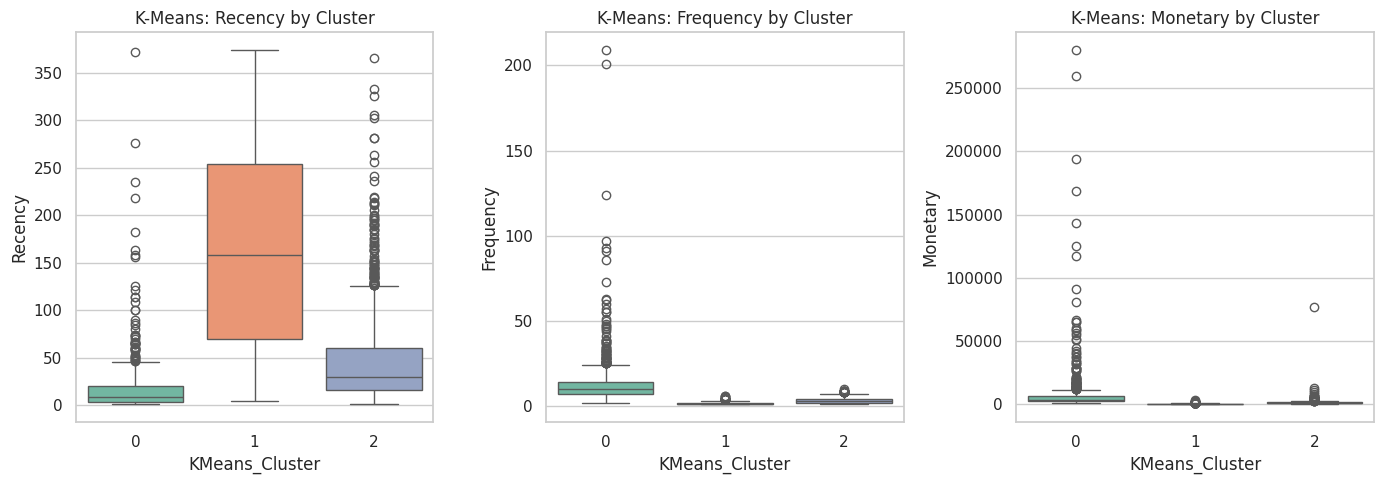

In [12]:
optimal_k = 3

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans_model.fit_predict(rfm_scaled_df)

print(f"--- K-Means Cluster Distribution (k={optimal_k}) ---")
print(rfm['KMeans_Cluster'].value_counts())

print("\n--- Mean RFM Values by K-Means Cluster ---")
display(rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

# Boxplots for K-Means
plt.figure(figsize=(14, 5))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='KMeans_Cluster', y=col, data=rfm, palette='Set2')
    plt.title(f'K-Means: {col} by Cluster')
plt.tight_layout()
plt.show()

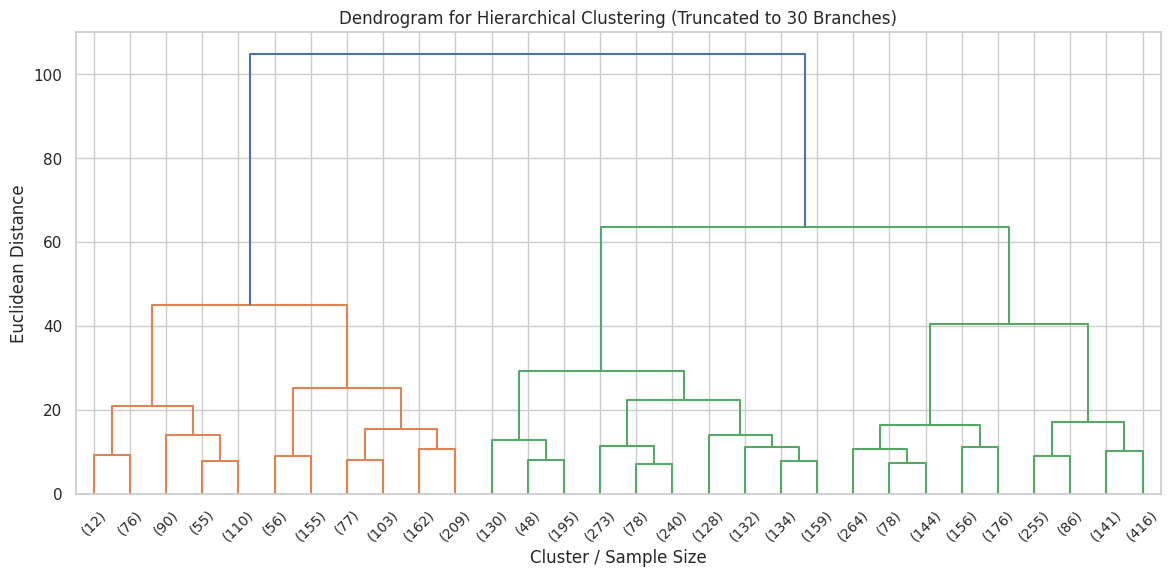


--- Hierarchical Cluster Distribution (k=3) ---
Hierarchical_Cluster
1    1716
2    1517
0    1105
Name: count, dtype: int64

--- Mean RFM Values by Hierarchical Cluster ---


,Recency,Frequency,Monetary
Hierarchical_Cluster,,,
0,10.714932,10.059729,5483.144534
1,146.576923,1.262821,270.308351
2,91.006592,3.460119,1558.658572


/tmp/ipykernel_626/1106754669.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hierarchical_Cluster', y=col, data=rfm, palette='Set3')
/tmp/ipykernel_626/1106754669.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hierarchical_Cluster', y=col, data=rfm, palette='Set3')
/tmp/ipykernel_626/1106754669.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hierarchical_Cluster', y=col, data=rfm, palette='Set3')


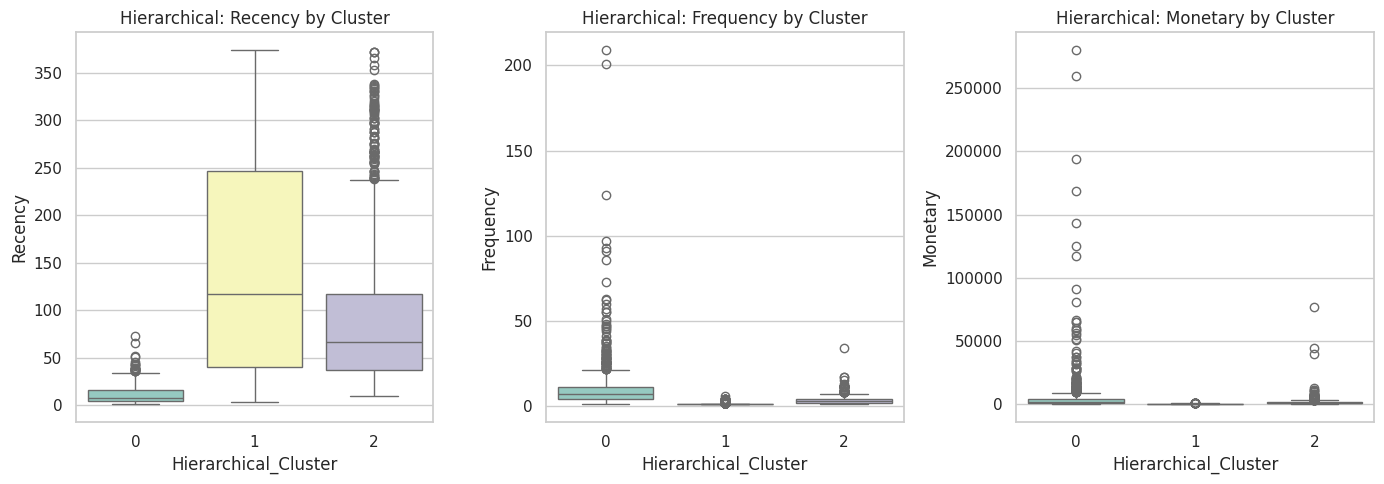

In [13]:
# Plot Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage(rfm_scaled_df, method='ward'), truncate_mode='lastp', p=30)
plt.title('Dendrogram for Hierarchical Clustering (Truncated to 30 Branches)')
plt.xlabel('Cluster / Sample Size')
plt.ylabel('Euclidean Distance')
plt.show()

# Agglomerative Clustering
optimal_h_k = 3
hierarchical_model = AgglomerativeClustering(n_clusters=optimal_h_k, metric='euclidean', linkage='ward')
rfm['Hierarchical_Cluster'] = hierarchical_model.fit_predict(rfm_scaled_df)

print(f"\n--- Hierarchical Cluster Distribution (k={optimal_h_k}) ---")
print(rfm['Hierarchical_Cluster'].value_counts())

print("\n--- Mean RFM Values by Hierarchical Cluster ---")
display(rfm.groupby('Hierarchical_Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

# Boxplots for Hierarchical Clustering
plt.figure(figsize=(14, 5))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Hierarchical_Cluster', y=col, data=rfm, palette='Set3')
    plt.title(f'Hierarchical: {col} by Cluster')
plt.tight_layout()
plt.show()

In [14]:
# Map cluster IDs based on your mean RFM outputs
segment_map = {
    0: 'At-Risk / Lost',
    1: 'Regular Customers',
    2: 'Champions / VIPs'
}

# Apply mapping
rfm['Customer_Segment'] = rfm['KMeans_Cluster'].map(segment_map)

# Verify distribution and average spend per segment
display(rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2))

Recency Frequency Monetary      
                     mean      mean     mean count
Customer_Segment                                  
At-Risk / Lost      17.06     13.35  7898.46   769
Champions / VIPs    44.20      3.38  1259.58  1697
Regular Customers  167.36      1.35   361.00  1872